# win_analytics_v2 — Prescriptor operacional por escalón del horno Ausmelt de Sn (modelo ganador v8, iteración 10)

**Objetivo.** Recomendar, escalón a escalón de la **Reducción**, la operación de las variables de CONTROL del reductor y la lanza
(tasa de carbón y de gas natural; O₂ y aire congelados al plan) dado el ESTADO al cierre del escalón anterior (leyes de escoria,
inventarios de Sn y FeO por cierre físico de masa, térmico, lanza, historia de dosificación), de modo que el batch termine con
**mayor recuperación de Sn a metal**; y fijar la **receta de Fusión** (sin recomendación por escalón: ninguna palanca de Fusión
tiene efecto identificado sobre el rendimiento).

**Qué es v8** (`modelo_predictivo_v8.py`, ficha `candidate_win_model_v8.md`, hallazgos §22). Es el núcleo predictivo de v7 (masa de
escoria por cierre físico, targets log telescópicos, modelo parcialmente lineal `y = g(S) + Σ θ_j (a_j − E[a_j|S])` con cross-fitting
por batch, estado parsimonioso) con las **correcciones de la fase 0 del dictamen del comité** (`dictamen_comite_v7.md`) y las mejoras que
sobrevivieron a la iteración 10 (`experimentos/v8/`):

| Componente | v7 | v8 (por qué) |
|---|---|---|
| Identificación de θ | acotado por signo (la cota fabricaba significancia) | **θ libre y acotado sobre los mismos residuos**; θ de uso = 0 si el IC libre no excluye 0 (E10-01/02) |
| Target de FeO | `ln(FeO_t / FeO_{t−1})` | **descuenta el FeO equivalente del Fe metálico del dross alimentado** (R0): R² 0.33 → 0.43 OOF, GN identificado (E10-02) |
| Estado de Reducción | 16 con `espesor` (reloj de campaña) | **15 sin `espesor`**; variante **plan** (cierre de F6 para todo R, ejecutable sin latencia de laboratorio, E10-03) |
| Forma del carbón | `Cx_sn` | `Cx_sn = C · Sn disponible` (única forma identificada; dosis saturante y curvatura no identificadas, E10-01) |
| Objetivo | K 3.52 / w 7.86 con legado | **K 2.78 / w 5.93 [4.0, 9.6] sin legado**; sensibilidad w ∈ [2, 11], legado y objetivo lineal en kg λ = 3 (E10-04) |
| Optimizador | P1-P99 global, aire libre, IC constante | **caja por orden**: P5-P95 ∩ |Δ| ≤ 1 sd, carbón R0 ≤ P90, aire/O₂ congelados, soporte < P10 → sin recomendación, ventana térmica dura, IC dependiente de la acción |
| Fusión | conservar Sn (β_F −0.58) | **β_F = 0**; ΔT sin F1; polvo y dross se cancelan → receta (E10-06) |
| Evidencia | adherencia vs KPI (sin potencia) | dosis-respuesta residual por escalón, residuo de la acción → KPI, uplift con IC propagado, **evaluación cruzada** (anti-maldición del optimizador) |

**Validación.** OOF GroupKFold(5) por batch sobre DEV (299 batches, abril-julio 2026) para elegir; OOF cronológico y walk-forward
(criterio de generalización, por el dictamen); lockbox = últimos 63 batches (agosto 2026, fin de campaña) sólo reporte y declarado
"gastado" por el comité.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import statsmodels.api as sm

import modelo_prescriptivo as mp
import modelo_predictivo_v8 as mp8
import sys; sys.path.insert(0, "experimentos/v8"); import v8_lib as L8

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 120)
EXP = Path("experimentos/v8")
RECALCULAR = False   # True: recalcula tablas pesadas (validacion, cross-fitting) en vez de leer experimentos/v8/e10_05_*.csv

df = mp8.cargar_df()                    # df v6 + columnas m8_* (cache experimentos/cache/df_v8.pkl)
df_base = mp8._preparar_base(df)
batches_dev, batches_lockbox = mp.split_dev_lockbox(df)
F, R = df_base["fase_proceso"] == "Fusión", df_base["fase_proceso"] == "Reducción"
print(f"escalones {df_base.shape[0]} (Fusión {F.sum()}, Reducción {R.sum()}) | batches DEV {len(batches_dev)} | lockbox {len(batches_lockbox)}")
print("targets:", mp8.TARGETS_V8); print("config:", {k: v for k, v in mp8.CONFIG_V8.items() if k != "ordenes_sin_recomendacion"})

escalones 3620 (Fusión 2172, Reducción 1448) | batches DEV 299 | lockbox 63
targets: {'Reducción': {'sn_dep': 'm6_ln_sn_dep', 'feo_ret': 'm8_ln_feo_ret_dross50', 'dT': 'd_temperatura_horno_celsius'}, 'Fusión': {'dT': 'd_temperatura_horno_celsius'}}
config: {'w_sdi': 5.93, 'pp_kpi_por_unidad_sdi': 2.781, 'w_sdi_ic': (3.96, 9.62), 'lambda_kg': 3.0, 'pp_kpi_por_kg_sn': 0.001951219512195122, 'pp_kpi_por_kg_carbon_F': 0.0, 'solo_identificados': True, 'delta_max_sd': 1.0, 'techo_carbon_R0_pct': 0.9, 'percentil_limites': (0.05, 0.95), 'percentil_soporte_minimo': 0.1, 'ventana_T_percentiles': (0.1, 0.9), 'fusion_modo': 'receta', 'congelar_fusion_fin_campana': True, 'lambda_lanza_constante': True, 'exigir_ganancia_fisica': True, 'robustez_w': (3.96, 9.62)}


## 1. Fundamento pirometalúrgico: STATE, CONTROL, targets y su agregación

**Batch** = 7 escalones de Fusión (carga, lanza oxidante, formación de la escoria FeO–SiO₂–CaO) + 4 de Reducción (sin carga:
`SnO₂ + 2C → Sn + 2CO` compite con `FeO + C → Fe + CO`; el Fe metalizado forma hardhead/dross que arrastra Sn; la temperatura y el
arrastre generan polvo).

**Masa de escoria por cierre físico** (`experimentos/v6/masa_v6.py`): `r_t = 1 − 1.270·s_t − f_t` (fracción no reducible),
`M_t·r_t = M_{t−1}·r_{t−1}·e^{−0.01} + 0.703·cal_t + 0.301·carga_t`; `Sn_inv = M·s`, `FeO_inv = M·f` (FeO ≡ 1.2865·Fe total).

**Targets por escalón** (adimensionales, log, telescópicos):

| Target | Fórmula | Sentido pirometalúrgico | Agregación |
|---|---|---|---|
| `m6_ln_sn_dep` | `ln((Sn_inv[t−1] + Sn alimentado[t]) / Sn_inv[t])` | agotamiento del Sn de la escoria (cinética aparente de 1er orden) | Σ_R = `ln(Sn_ini/Sn_fin)` (exacto) |
| `m8_ln_feo_ret_dross50` | `ln(FeO_inv[t] / (FeO_inv[t−1] + 1.2865·0.5·dross_Fe[t]))` | retención del Fe en escoria **neta del Fe metálico alimentado** (≤ 0 si se metaliza Fe: hardhead) | Σ_R = `ln(FeO_fin/(FeO_ini + Fe alimentado))` |
| `d_temperatura_horno_celsius` | ΔT del horno | ventana térmica (restricción, no objetivo) | — |

**Objetivo por escalón y agregación** (anclado en el KPI refinado `recuperacion_refinada_pct = 100·M/(M+D+P+Sn escoria final)`):
`J_t = K·(ln_sn_dep_t + w·ln_feo_ret_t) − costos_t − w_U·sd_J(acción) − w_S·max(0, s_hist − s)`, K = 2.78 pp/unidad (× 512 kg Sn/pp),
w = 5.93 [3.96, 9.62]; `J_grupo = Σ J_t` (R temprano R0-R1, R tardío R2-R3); `J_R = K·[ln(Sn_ini/Sn_fin) + w·ln(FeO_fin/FeO_ini')] − Σ costos`
(identidad telescópica exacta); `J_batch = J_R + J_F` con `J_F = −costos` (β_F = 0).

**Roles.** STATE (15): leyes previas %Sn, %FeO, %SiO₂, %CaO, `ratio_sn_feo_prev`, `interaccion_Sn_x_FeO_prev`, termocupla y gradiente de T,
lanza previa, carbón y aire acumulados, C/Sn acumulado, inventarios de Sn y FeO y fracción no reducible (cierre físico). CONTROL:
`tasa_feed_Carbon_kg_min` (vía `Cx_sn_v6 = C·Sn_inv_prev/1000`, `m8_exceso_C_pos`, `Cx_av_v6`), `tasa_gn_nm3_min`; `exceso_o2` y `aire` en el
modelo pero **congelados** (setpoint de protección de lanza; sin efecto identificado). PLAN: carga, cal, duración, O₂, aire.

In [2]:
for fase in mp8.FASES:
    print(f"=== {fase} ===")
    for clave, tgt in mp8.TARGETS_V8[fase].items():
        S, A = mp8.ESTADO_V8[(fase, clave)], mp8.PALANCAS_V8[(fase, clave)]
        print(f"  target {tgt:28s} | estado g(S): {len(S):2d} vars | palancas theta: {A}")
    print("  CONTROL optimizable:", mp8.ACCIONES_OPTIMIZABLES_V8[fase], "| congeladas:", mp8.ACCIONES_CONGELADAS_V8)
print(df_base.loc[R, ["m6_ln_sn_dep", "m6_ln_feo_ret", "m8_ln_feo_ret_dross50", "d_temperatura_horno_celsius"]].describe().round(3).T)

=== Fusión ===
  target d_temperatura_horno_celsius  | estado g(S):  7 vars | palancas theta: ['tasa_gn_nm3_min', 'tasa_o2_nm3_min', 'tasa_aire_nm3_min', 'tasa_feed_Carbon_kg_min']
  CONTROL optimizable: ['tasa_feed_Carbon_kg_min'] | congeladas: ['tasa_o2_nm3_min', 'tasa_aire_nm3_min']
=== Reducción ===
  target m6_ln_sn_dep                 | estado g(S): 15 vars | palancas theta: ['Cx_sn_v6', 'tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'tasa_aire_nm3_min']
  target m8_ln_feo_ret_dross50        | estado g(S): 15 vars | palancas theta: ['m8_exceso_C_pos', 'Cx_av_v6', 'tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'tasa_aire_nm3_min']
  target d_temperatura_horno_celsius  | estado g(S):  5 vars | palancas theta: ['tasa_gn_nm3_min', 'tasa_o2_nm3_min', 'tasa_aire_nm3_min', 'tasa_feed_Carbon_kg_min']
  CONTROL optimizable: ['tasa_feed_Carbon_kg_min', 'tasa_gn_nm3_min'] | congeladas: ['tasa_o2_nm3_min', 'tasa_aire_nm3_min']
                              count   mean     std     min     25

### 1.1 Por qué estos targets: anclaje en el rendimiento del batch (E10-04a/b)

El KPI refinado del batch regresado (OLS HC3, controles de ley, refractario, Sn cargado, carga secundaria, dross de Fe y tendencia)
sobre las sumas telescópicas de Reducción da K_Sn ≈ 2.8 pp por unidad de agotamiento y K_FeO ≈ 16.5 pp por unidad de retención →
w ≈ 5.9. El anclaje es invariante a la agregación (suma por escalón = cociente de inventarios) y al target de FeO (v7 vs corregido por
dross). En el lockbox (fin de campaña, horno frío) w cae a ≈ 0.8 (el KPI premia agotar Sn): por eso la política se exige robusta en w ∈ [2, 11].

,target,muestra,y,n,K_sn,K_sn_lo,K_sn_hi,K_feo,K_feo_lo,K_feo_hi,K_feo_p,w,w_boot_lo,w_boot_hi
0,m6_ln_feo_ret,dev,KPI,297,2.853,1.668,4.037,17.262,11.044,23.480,0.000,6.051,4.108,9.625
1,m6_ln_feo_ret,lockbox,KPI,63,4.053,1.421,6.684,2.819,-12.745,18.384,0.723,0.696,-5.902,3.861
2,m6_ln_feo_ret,total,KPI,360,3.218,2.184,4.252,15.708,10.002,21.414,0.000,4.881,3.414,6.827
3,m6_ln_feo_ret,dev,KPI_next,297,0.669,-0.742,2.081,10.416,4.979,15.853,0.000,15.559,4.882,123.521
4,m6_ln_feo_ret,total,KPI_next,359,0.765,-0.524,2.053,11.357,6.233,16.481,0.000,14.848,5.714,112.632
16,m8_ln_feo_ret_dross50,dev,KPI,297,2.781,1.599,3.962,16.489,10.296,22.681,0.000,5.929,3.959,9.620
17,m8_ln_feo_ret_dross50,lockbox,KPI,63,4.108,1.328,6.888,3.406,-13.352,20.164,0.690,0.829,-6.734,4.070
18,m8_ln_feo_ret_dross50,total,KPI,360,3.207,2.176,4.237,15.579,9.850,21.308,0.000,4.858,3.338,6.839
19,m8_ln_feo_ret_dross50,dev,KPI_next,297,0.608,-0.755,1.972,9.771,4.299,15.243,0.000,16.061,4.454,172.065
20,m8_ln_feo_ret_dross50,total,KPI_next,359,0.750,-0.503,2.003,11.262,6.127,16.397,0.000,15.013,5.579,121.517


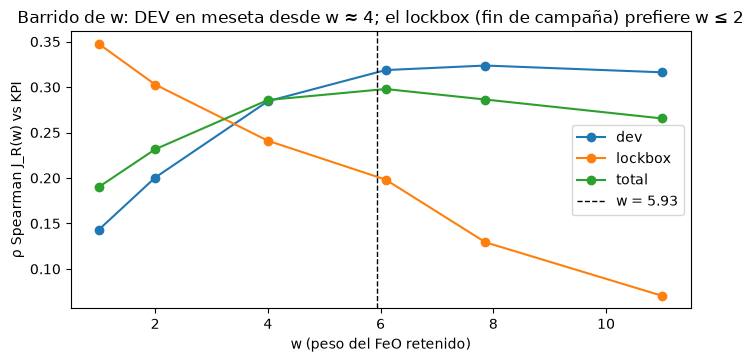

In [3]:
anc = pd.read_csv(EXP / "e10_04b_reanclaje.csv")
display(anc[anc.y.isin(["KPI", "KPI_next"]) & anc.target.isin(["m6_ln_feo_ret", "m8_ln_feo_ret_dross50"])][["target", "muestra", "y", "n", "K_sn", "K_sn_lo", "K_sn_hi", "K_feo", "K_feo_lo", "K_feo_hi", "K_feo_p", "w", "w_boot_lo", "w_boot_hi"]].round(3))
sw = pd.read_csv(EXP / "e10_04a_barrido_w.csv")
fig, ax = plt.subplots(figsize=(8, 3.6))
for m, c in [("dev", "#1f77b4"), ("lockbox", "#ff7f0e"), ("total", "#2ca02c")]:
    s = sw[(sw.muestra == m) & (sw.tercio == "todos")]; ax.plot(s.w, s.rho, "o-", label=m, color=c)
ax.axvline(mp8.CONFIG_V8["w_sdi"], color="k", ls="--", lw=1, label=f"w = {mp8.CONFIG_V8['w_sdi']}")
ax.set_xlabel("w (peso del FeO retenido)"); ax.set_ylabel("ρ Spearman J_R(w) vs KPI"); ax.set_title("Barrido de w: DEV en meseta desde w ≈ 4; el lockbox (fin de campaña) prefiere w ≤ 2"); ax.legend(); plt.show()

## 2. Construcción del modelo y efecto de las variables de CONTROL (θ libre y acotado)

`mp8.entrenar_sistema_v8` entrena sólo con DEV un `ModeloPLMDual` por (fase, target): `g(S)` y `E[a_j|S]` con HistGradientBoosting
cross-fitted (GroupKFold por batch), θ por mínimos cuadrados **libres** y **acotados por el signo de la teoría** sobre los mismos residuos,
IC95 % bootstrap por batch (500) para ambos. **Una palanca entra al objetivo sólo si su IC libre excluye 0**; si no, θ de uso = 0 y se declara
"no identificada" (no "≈ 0"). Además: soporte histórico kNN, límites P5-P95 y ventana térmica P10-P90 **por orden de escalón**.

In [4]:
sistema = mp8.entrenar_sistema_v8(df, n_boot=300)
efectos = mp8.tabla_efectos_control_v8(sistema)
display(efectos[["fase", "clave", "palanca", "signo_teorico", "theta_libre_1sd", "ci_lo_libre_1sd", "ci_hi_libre_1sd", "theta_acot_1sd", "frac_replicas_en_cota", "identificado", "theta_uso_1sd"]].round(4))

,fase,clave,palanca,signo_teorico,theta_libre_1sd,ci_lo_libre_1sd,ci_hi_libre_1sd,theta_acot_1sd,frac_replicas_en_cota,identificado,theta_uso_1sd
0,Fusión,dT,tasa_gn_nm3_min,1,-0.2929,-2.1574,1.0858,0.0000,0.5133,False,0.0000
1,Fusión,dT,tasa_o2_nm3_min,0,-2.0906,-3.4699,-0.5581,-2.2757,0.0000,True,-2.2757
2,Fusión,dT,tasa_aire_nm3_min,-1,0.5755,-1.1229,2.0766,-0.0000,0.7100,False,0.0000
3,Fusión,dT,tasa_feed_Carbon_kg_min,0,0.2813,-0.8273,1.3434,0.3201,0.0000,False,0.0000
4,Reducción,sn_dep,Cx_sn_v6,1,0.1786,0.0402,0.2969,0.1786,0.0033,True,0.1786
5,Reducción,sn_dep,tasa_gn_nm3_min,1,0.0563,0.0217,0.0958,0.0563,0.0033,True,0.0563
6,Reducción,sn_dep,exceso_o2_combustion_pct,-1,-0.0039,-0.0213,0.0138,-0.0039,0.3100,False,0.0000
7,Reducción,sn_dep,tasa_aire_nm3_min,0,0.0059,-0.0109,0.0217,0.0059,0.0000,False,0.0000
8,Reducción,feo_ret,m8_exceso_C_pos,-1,0.0031,-0.0043,0.0111,-0.0000,0.8700,False,0.0000
9,Reducción,feo_ret,Cx_av_v6,-1,-0.0025,-0.0168,0.0094,-0.0000,0.6367,False,0.0000


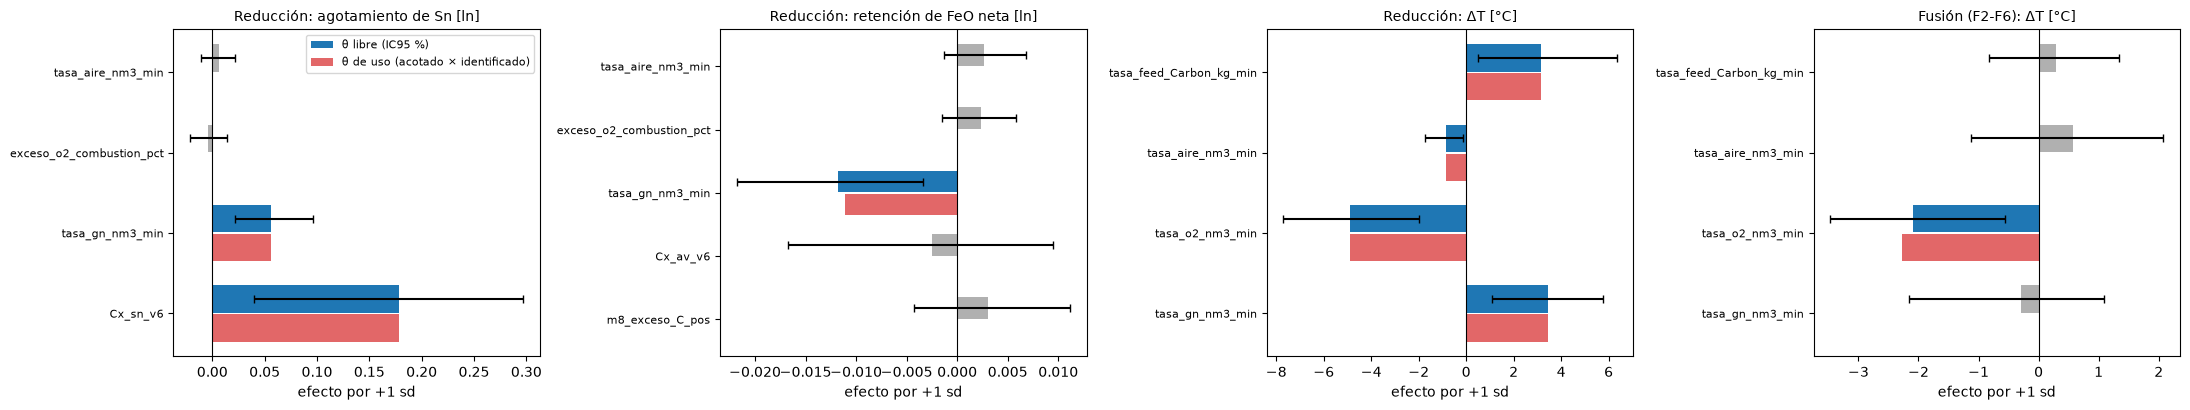

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.2))
for ax, (fase, clave, titulo) in zip(axes, [("Reducción", "sn_dep", "Reducción: agotamiento de Sn [ln]"), ("Reducción", "feo_ret", "Reducción: retención de FeO neta [ln]"),
                                         ("Reducción", "dT", "Reducción: ΔT [°C]"), ("Fusión", "dT", "Fusión (F2-F6): ΔT [°C]")]):
    e = efectos[(efectos.fase == fase) & (efectos.clave == clave)]; y = np.arange(len(e))
    ax.barh(y + 0.18, e["theta_libre_1sd"], height=0.34, xerr=[e["theta_libre_1sd"] - e["ci_lo_libre_1sd"], e["ci_hi_libre_1sd"] - e["theta_libre_1sd"]], color=np.where(e["identificado"], "#1f77b4", "#b0b0b0"), capsize=3, label="θ libre (IC95 %)")
    ax.barh(y - 0.18, e["theta_uso_1sd"], height=0.34, color="#d62728", alpha=0.7, label="θ de uso (acotado × identificado)")
    ax.set_yticks(y); ax.set_yticklabels(e["palanca"], fontsize=8); ax.axvline(0, color="k", lw=0.8); ax.set_title(titulo, fontsize=10); ax.set_xlabel("efecto por +1 sd")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

**Lectura.** En Reducción el **carbón × Sn disponible** sube el agotamiento de Sn (θ libre > 0, IC que excluye 0: la palanca se
identifica sin recurrir a la cota) y el **GN** sube el agotamiento y **baja la retención de FeO** (reductor no selectivo; con el estado sin
`espesor` y el target neto del Fe alimentado su IC libre sobre FeO excluye 0). El carbón sobre la retención de FeO **no está identificado**
(IC libre ±0.04, réplicas en la cota > 50 %): el prescriptor no le asigna efecto y por eso la recomendación de carbón es una dirección con
paso acotado, no un óptimo. Exceso de O₂ y aire: sin efecto identificado en ningún target → congelados. En Fusión ninguna palanca tiene
efecto térmico identificado (el O₂ "significativo" de v7 era cota + control reactivo).

## 3. Métricas de predicción (OOF aleatorio = selección; OOF cronológico y walk-forward = generalización; lockbox = reporte)

In [6]:
tabla = mp8.tabla_validacion_v8(df) if RECALCULAR else pd.read_csv(EXP / "e10_05_tabla_validacion_v8.csv")
display(tabla[["fase", "target", "columna", "forma", "n_estado", "n_palancas", "n_dev", "n_lockbox", "r2_oof", "mae_oof", "r2_oof_cronologico", "r2_walk_forward", "r2_lockbox", "mae_lockbox", "sd_target_dev"]].round(3))
print("Referencia v7 (candidate_win_model_v7.md): Sn 0.767/0.795, FeO 0.333/0.483 (OOF/lockbox), OOF cronológico FeO 0.296, walk-forward 0.261")
print("Comparación de targets y estados (E10-02) y del estado ejecutable (E10-03):")
for f in ["e10_02_targets_estados.csv", "e10_03_estados.csv"]:
    if (EXP / f).exists(): display(pd.read_csv(EXP / f).round(3))

,fase,target,columna,forma,n_estado,n_palancas,n_dev,n_lockbox,r2_oof,mae_oof,r2_oof_cronologico,r2_walk_forward,r2_lockbox,mae_lockbox,sd_target_dev
0,Fusión,dT,d_temperatura_horno_celsius,PLM_v8,7,4,1482,314,0.480,9.095,0.359,0.166,0.050,7.044,17.185
1,Fusión,dT,d_temperatura_horno_celsius,HGB_estado+palancas_ref,7,4,1482,314,0.456,9.312,0.322,NaN,-0.011,7.319,17.185
2,Reducción,sn_dep,m6_ln_sn_dep,PLM_v8,15,4,1083,242,0.767,0.247,0.775,0.771,0.800,0.242,0.677
3,Reducción,sn_dep,m6_ln_sn_dep,HGB_estado+palancas_ref,15,4,1083,242,0.760,0.251,0.765,NaN,0.805,0.239,0.677
4,Reducción,feo_ret,m8_ln_feo_ret_dross50,PLM_v8,15,5,1083,242,0.438,0.047,0.416,0.333,0.566,0.043,0.083
5,Reducción,feo_ret,m8_ln_feo_ret_dross50,HGB_estado+palancas_ref,15,5,1083,242,0.442,0.047,0.398,NaN,0.536,0.044,0.083
6,Reducción,dT,d_temperatura_horno_celsius,PLM_v8,5,4,1182,252,0.440,9.451,0.264,-0.016,0.423,6.531,17.538
7,Reducción,dT,d_temperatura_horno_celsius,HGB_estado+palancas_ref,5,4,1182,252,0.427,9.492,0.222,NaN,0.355,7.017,17.538


Referencia v7 (candidate_win_model_v7.md): Sn 0.767/0.795, FeO 0.333/0.483 (OOF/lockbox), OOF cronológico FeO 0.296, walk-forward 0.261
Comparación de targets y estados (E10-02) y del estado ejecutable (E10-03):


,n_dev,n_lockbox,r2_oof,mae_oof,r2_oof_cronologico,r2_walk_forward,n_walk_forward,r2_lockbox,mae_lockbox,estado,familia,target,k_estado
0,1045,238,0.804,0.230,0.799,0.801,697,0.821,0.234,k16_v7,sn_dep,m6_ln_sn_dep,16
1,1045,238,0.550,0.405,0.544,0.537,697,0.593,0.402,k16_v7,sn_dep,m8_ln_sn_dep_cstar,16
2,1083,242,0.333,0.047,0.305,0.246,720,0.483,0.042,k16_v7,feo_ret,m6_ln_feo_ret,16
3,1083,242,0.429,0.046,0.399,0.317,720,0.540,0.043,k16_v7,feo_ret,m8_ln_feo_ret_dross40,16
4,1083,242,0.447,0.047,0.415,0.334,720,0.554,0.043,k16_v7,feo_ret,m8_ln_feo_ret_dross50,16
5,1083,242,0.464,0.047,0.434,0.349,720,0.561,0.044,k16_v7,feo_ret,m8_ln_feo_ret_dross60,16
6,1083,242,0.325,0.047,0.304,0.255,720,0.469,0.042,k15_sin_espesor,feo_ret,m6_ln_feo_ret,15
7,1083,242,0.424,0.046,0.395,0.325,720,0.556,0.042,k15_sin_espesor,feo_ret,m8_ln_feo_ret_dross40,15
8,1083,242,0.438,0.047,0.416,0.333,720,0.566,0.043,k15_sin_espesor,feo_ret,m8_ln_feo_ret_dross50,15
9,1083,242,0.460,0.047,0.430,0.351,720,0.574,0.043,k15_sin_espesor,feo_ret,m8_ln_feo_ret_dross60,15


,n_dev,n_lockbox,r2_oof,mae_oof,r2_oof_cronologico,r2_walk_forward,n_walk_forward,r2_lockbox,mae_lockbox,r2_oof_hgb_ref,estado,target,A
0,898,240,0.786,0.235,0.780,0.775,543,0.784,0.248,0.784,A_k15,sn_dep,"Cx_sn_v6,tasa_gn_nm3_min,exceso_o2_combustion_..."
1,898,240,0.697,0.288,0.697,0.695,543,0.756,0.264,0.692,B_online,sn_dep,"Cx_sn_online,tasa_gn_nm3_min,exceso_o2_combust..."
2,898,240,0.724,0.272,0.720,0.719,543,0.735,0.280,0.720,C_plan,sn_dep,"Cx_sn_F6,tasa_gn_nm3_min,exceso_o2_combustion_..."
3,898,240,0.309,0.048,0.272,0.241,543,0.473,0.042,0.302,A_k15,feo_ret,"tasa_feed_Carbon_kg_min,Cx_av_v6,tasa_gn_nm3_m..."
4,898,240,0.241,0.050,0.171,0.182,543,0.380,0.046,0.235,B_online,feo_ret,"tasa_feed_Carbon_kg_min,Cx_av_online,tasa_gn_n..."
5,898,240,0.242,0.050,0.187,0.181,543,0.392,0.045,0.259,C_plan,feo_ret,"tasa_feed_Carbon_kg_min,Cx_av_F6,tasa_gn_nm3_m..."


## 4. Real vs. predicho (scatter y evolutivo)

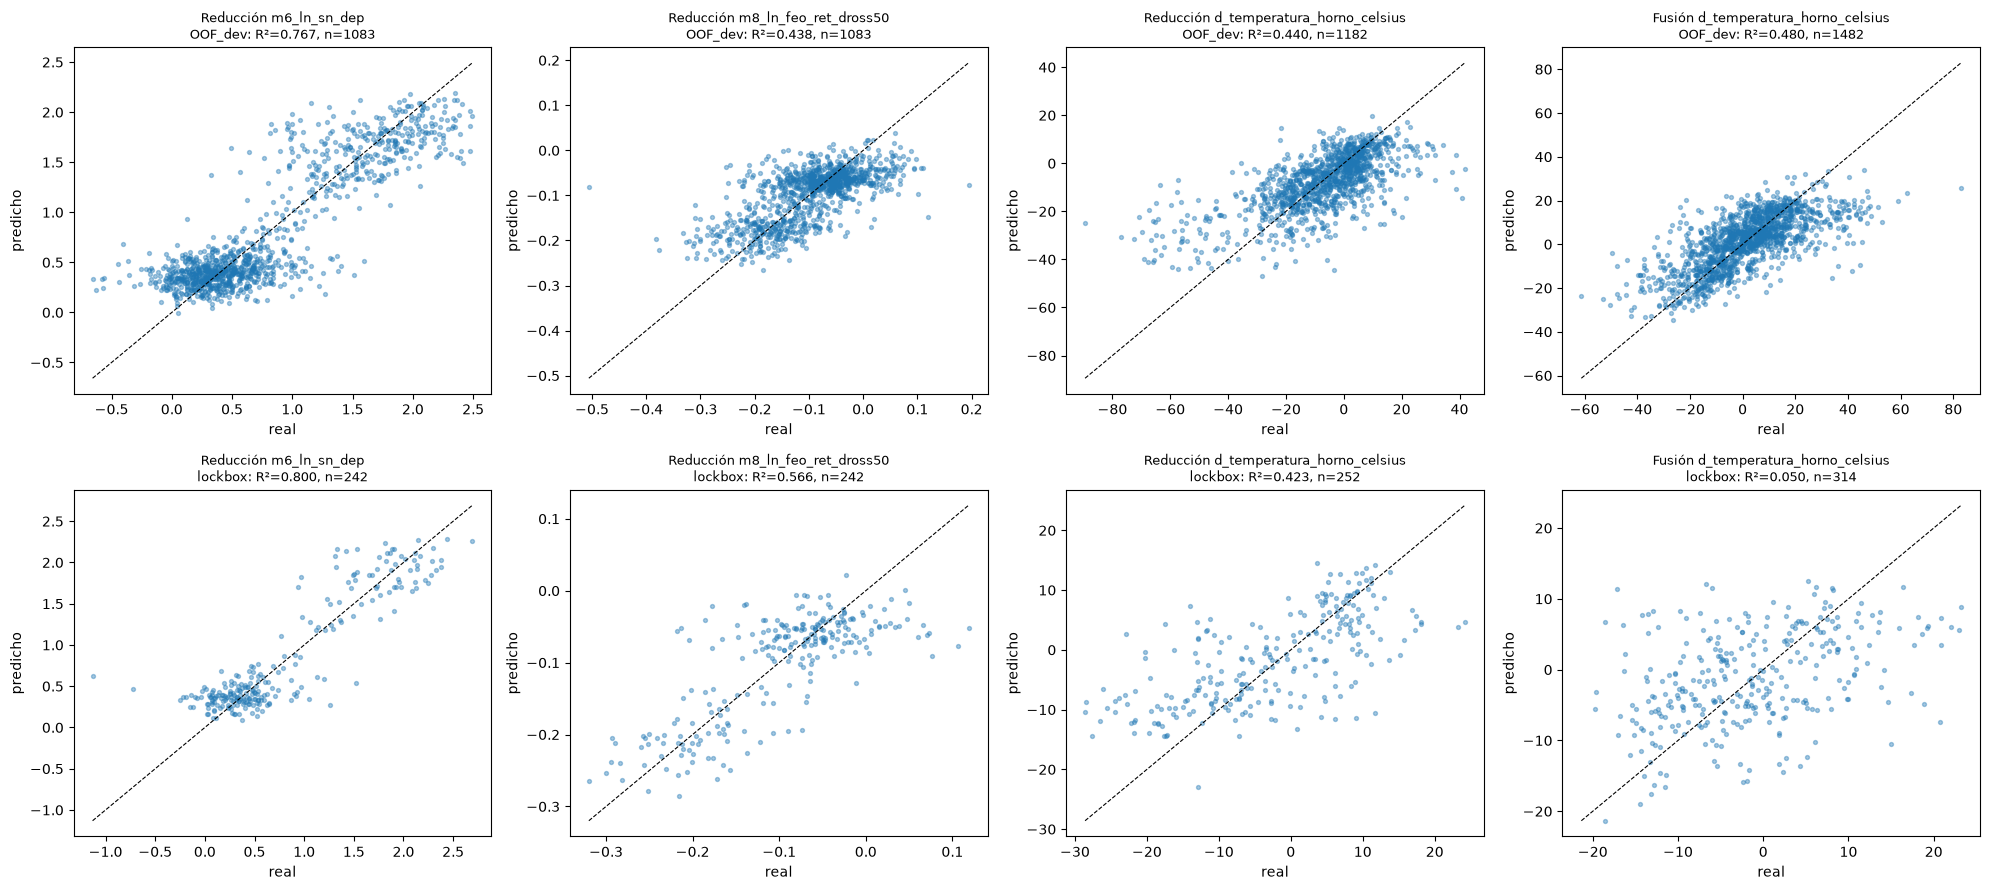

In [7]:
def cargar_pred(fase, clave):
    return mp8.predicciones_oof_y_lockbox_v8(df, fase, clave) if RECALCULAR else pd.read_csv(EXP / f"e10_05_pred_{fase}_{clave}.csv", parse_dates=["fecha_inicio"])

combos = [("Reducción", "sn_dep"), ("Reducción", "feo_ret"), ("Reducción", "dT"), ("Fusión", "dT")]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for j, (fase, clave) in enumerate(combos):
    p = cargar_pred(fase, clave)
    for i, conjunto in enumerate(["OOF_dev", "lockbox"]):
        q = p[p.conjunto == conjunto]; ax = axes[i, j]
        ax.scatter(q.real, q.pred, s=8, alpha=0.4)
        lim = [min(q.real.min(), q.pred.min()), max(q.real.max(), q.pred.max())]; ax.plot(lim, lim, "k--", lw=0.8)
        r2 = 1 - ((q.real - q.pred) ** 2).sum() / ((q.real - q.real.mean()) ** 2).sum()
        ax.set_title(f"{fase} {mp8.TARGETS_V8[fase][clave]}\n{conjunto}: R²={r2:.3f}, n={len(q)}", fontsize=9); ax.set_xlabel("real"); ax.set_ylabel("predicho")
plt.tight_layout(); plt.show()

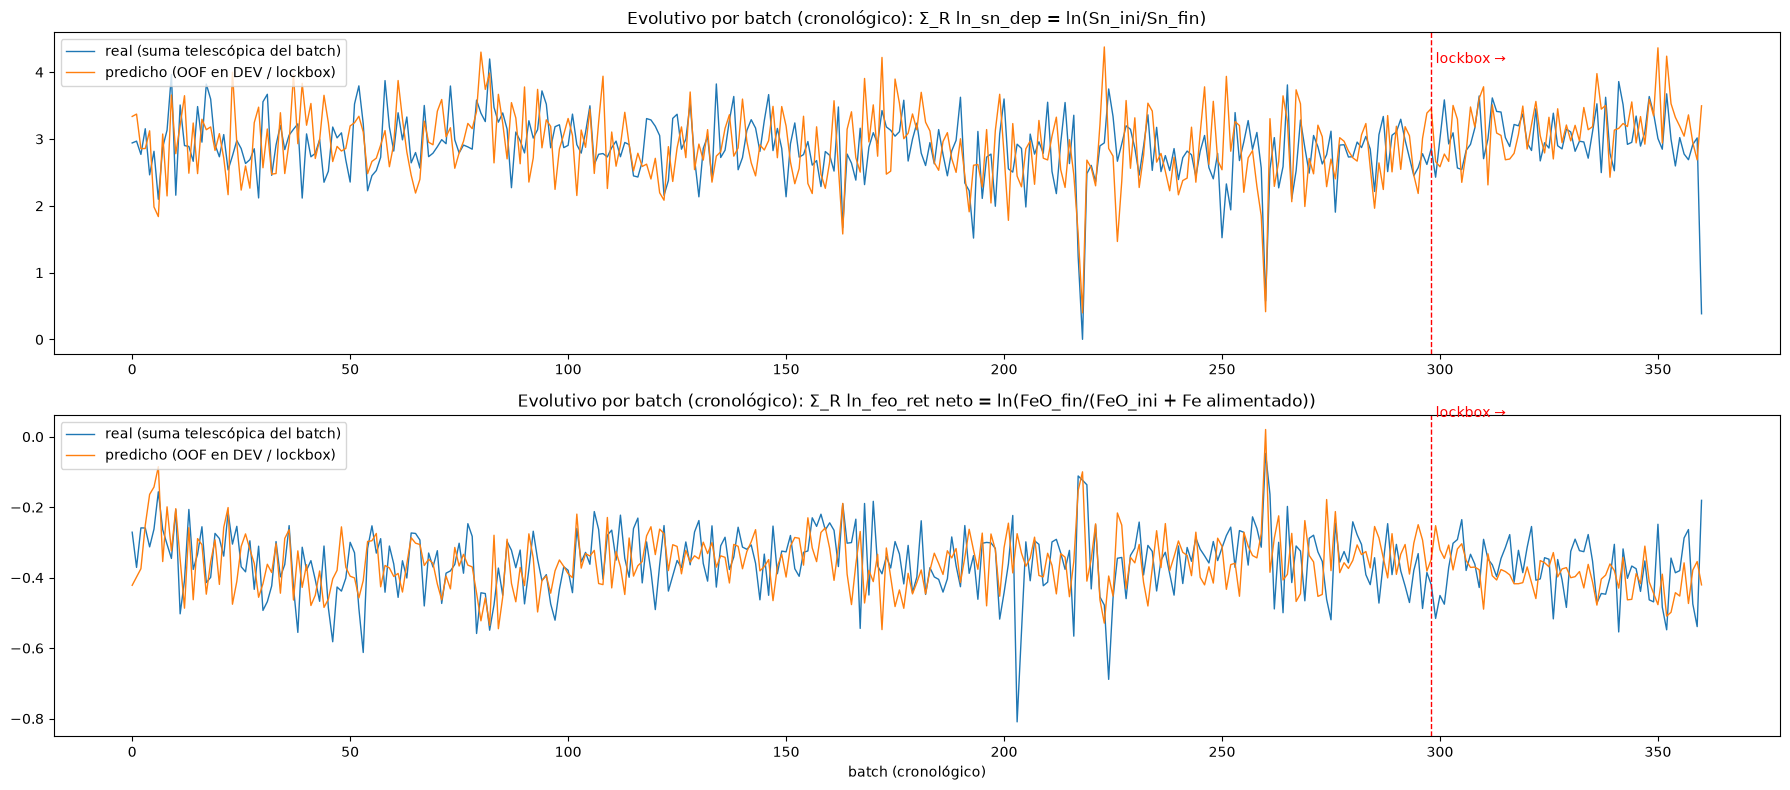

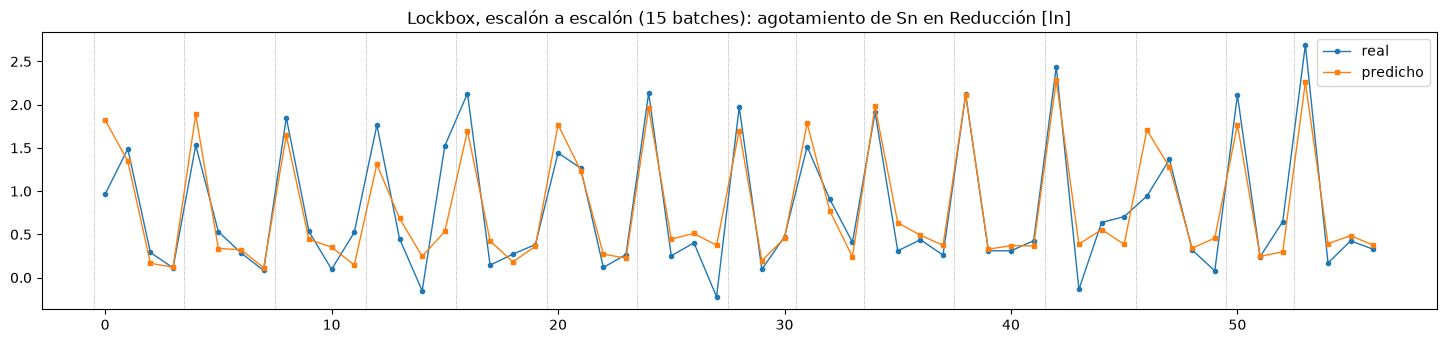

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8))
for ax, (fase, clave, lab) in zip(axes, [("Reducción", "sn_dep", "Σ_R ln_sn_dep = ln(Sn_ini/Sn_fin)"), ("Reducción", "feo_ret", "Σ_R ln_feo_ret neto = ln(FeO_fin/(FeO_ini + Fe alimentado))")]):
    p = cargar_pred(fase, clave)
    b = p.groupby("Batch").agg(fecha=("fecha_inicio", "min"), real=("real", "sum"), pred=("pred", "sum"), conjunto=("conjunto", "first")).sort_values("fecha")
    x = np.arange(len(b)); ax.plot(x, b.real, label="real (suma telescópica del batch)", lw=1); ax.plot(x, b.pred, label="predicho (OOF en DEV / lockbox)", lw=1)
    i0 = int((b.conjunto == "OOF_dev").sum()); ax.axvline(i0, color="r", ls="--", lw=1); ax.text(i0 + 1, ax.get_ylim()[1] * 0.9, "lockbox →", color="r")
    ax.set_title(f"Evolutivo por batch (cronológico): {lab}"); ax.legend(loc="upper left")
axes[-1].set_xlabel("batch (cronológico)"); plt.tight_layout(); plt.show()
p = cargar_pred("Reducción", "sn_dep"); q = p[p.conjunto == "lockbox"].sort_values("fecha_inicio"); q = q[q.Batch.isin(sorted(q.Batch.unique())[:15])].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(18, 3.6)); ax.plot(q.real, "o-", ms=3, lw=1, label="real"); ax.plot(q.pred, "s-", ms=3, lw=1, label="predicho")
for i in np.where(q.orden_escalon_fase == 0)[0]: ax.axvline(i - 0.5, color="grey", lw=0.5, ls=":")
ax.set_title("Lockbox, escalón a escalón (15 batches): agotamiento de Sn en Reducción [ln]"); ax.legend(); plt.show()

## 5. Interpretabilidad: SHAP del estado, dependencia parcial y curvas de respuesta de las palancas

El PLM separa el efecto del ESTADO (no lineal, `g(S)`: SHAP y dependencia parcial) del de las palancas (lineal, θ, sección 2). Las
curvas de respuesta del prescriptor (predicciones y `J` a lo largo de cada palanca en un estado real) son la dependencia parcial operativa.
Coherencia esperada por teoría: más %Sn previo → más agotamiento (fuerza motriz); más %FeO previo → más competencia (menos selectivo);
la retención de FeO es más negativa cuando queda poco Sn (avance alto) porque el reductor pasa a metalizar Fe.

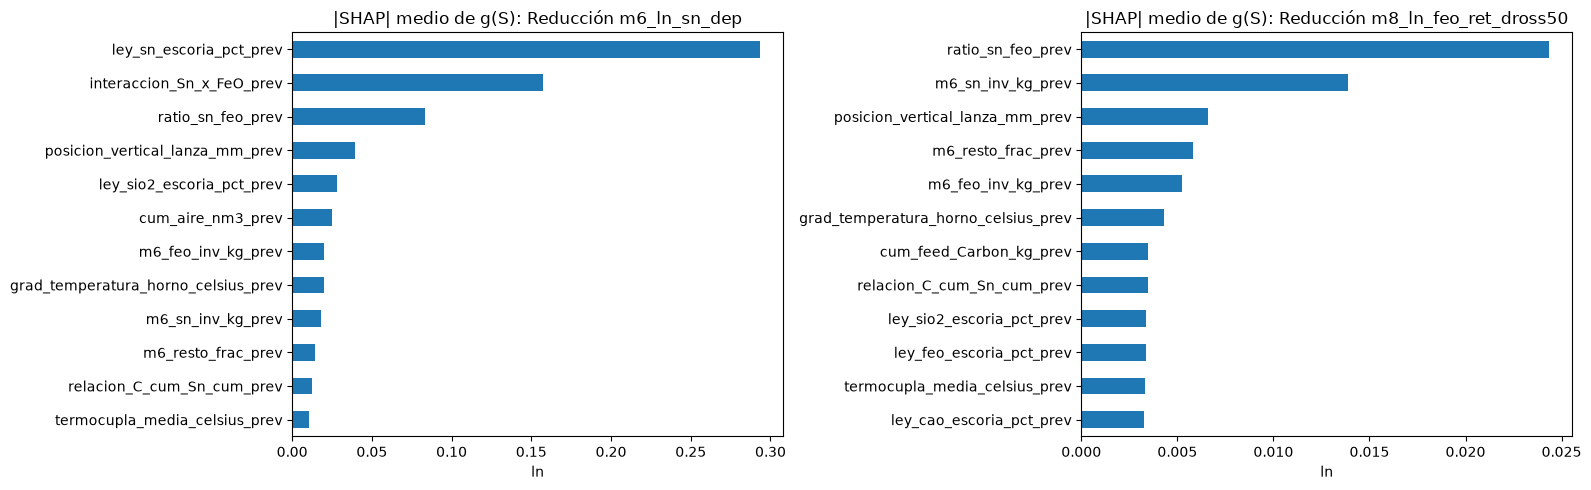

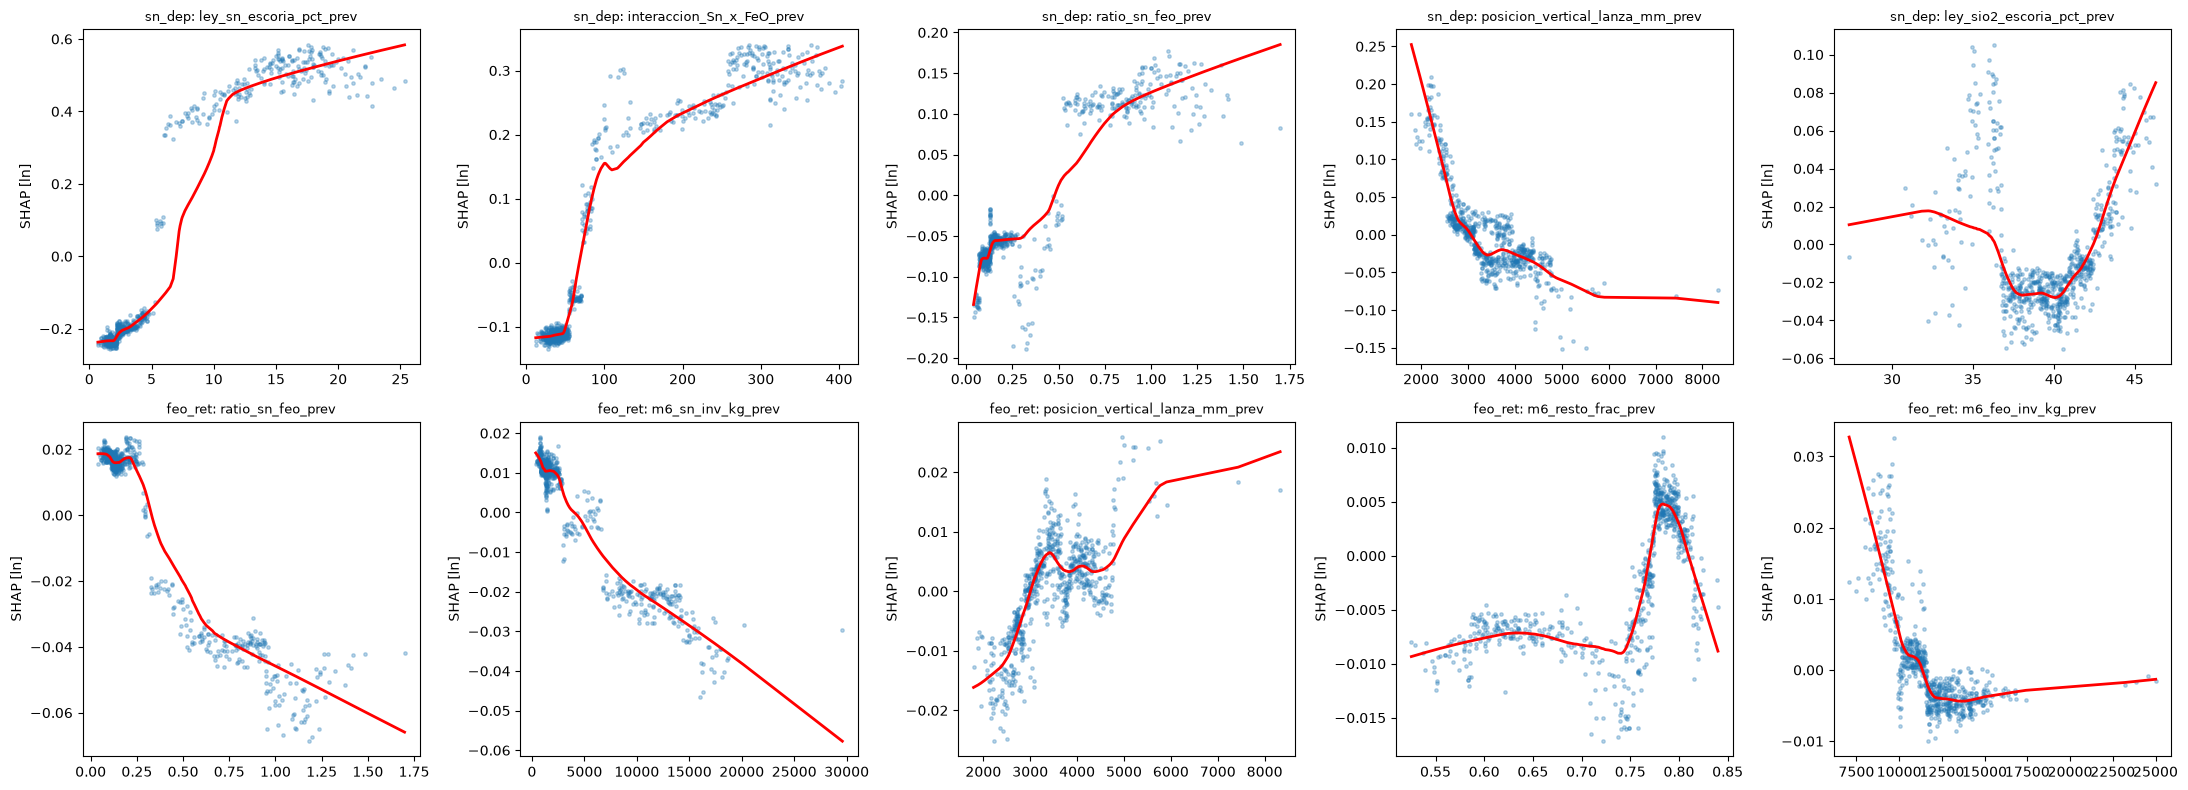

In [9]:
import shap
def shap_estado(fase, clave, n=700):
    m = sistema.modelos[(fase, clave)]
    d = df_base[(df_base.fase_proceso == fase) & df_base.Batch.isin(batches_dev)].dropna(subset=m.estado + [m.target]).sample(min(n, 5000), random_state=0)
    X = d[m.estado]; sv = shap.TreeExplainer(m.g).shap_values(X)
    return X, sv, pd.Series(np.abs(sv).mean(axis=0), index=m.estado).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (fase, clave) in zip(axes, [("Reducción", "sn_dep"), ("Reducción", "feo_ret")]):
    X, sv, imp = shap_estado(fase, clave); imp.head(12)[::-1].plot.barh(ax=ax); ax.set_title(f"|SHAP| medio de g(S): {fase} {mp8.TARGETS_V8[fase][clave]}"); ax.set_xlabel("ln")
plt.tight_layout(); plt.show()
from statsmodels.nonparametric.smoothers_lowess import lowess
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for i, (fase, clave) in enumerate([("Reducción", "sn_dep"), ("Reducción", "feo_ret")]):
    X, sv, imp = shap_estado(fase, clave)
    for j, f in enumerate(imp.index[:5]):
        ax = axes[i, j]; k = list(X.columns).index(f); ax.scatter(X[f], sv[:, k], s=6, alpha=0.3); ok = X[f].notna().to_numpy()
        lw = lowess(sv[ok, k], X[f].to_numpy()[ok], frac=0.3, return_sorted=True); ax.plot(lw[:, 0], lw[:, 1], "r-", lw=2); ax.set_title(f"{clave}: {f}", fontsize=9); ax.set_ylabel("SHAP [ln]")
plt.tight_layout(); plt.show()

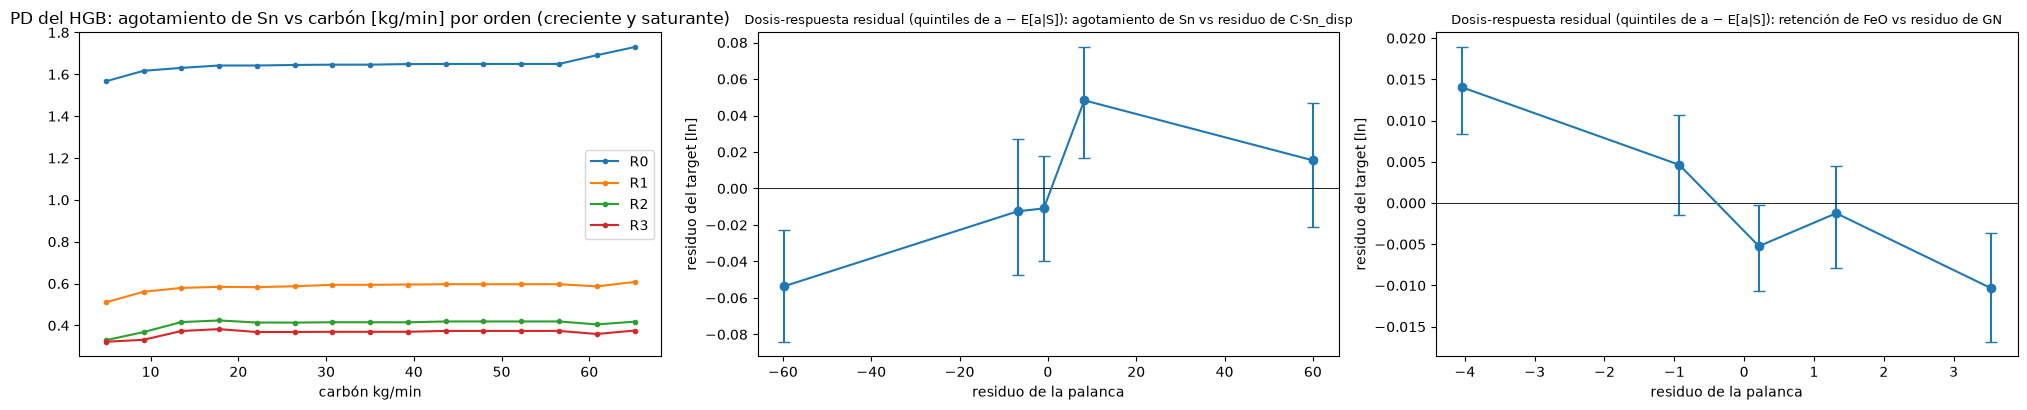

,clave,palanca,signo_teorico,n,spearman_residual,p,theta_libre_1sd,ci_lo_libre,ci_hi_libre,rho_tercio0,p_tercio0,rho_tercio1,p_tercio1,rho_tercio2,p_tercio2,grupo,ols_pp_por_sd,ols_p
0,sn_dep,Cx_sn_v6,1.0,1083,0.0803,0.0082,0.1786,0.0402,0.2969,0.0284,0.5897,0.1113,0.0361,0.1062,0.0427,NaN,NaN,NaN
1,sn_dep,tasa_gn_nm3_min,1.0,1083,0.1120,0.0002,0.0563,0.0217,0.0958,0.1258,0.0165,0.1026,0.0533,0.1089,0.0376,NaN,NaN,NaN
2,sn_dep,exceso_o2_combustion_pct,-1.0,1083,-0.0328,0.2807,-0.0039,-0.0213,0.0138,-0.0562,0.2857,0.0205,0.7008,-0.0562,0.2838,NaN,NaN,NaN
3,sn_dep,tasa_aire_nm3_min,0.0,1083,0.0111,0.7141,0.0059,-0.0109,0.0217,-0.0363,0.4907,0.1288,0.0152,-0.0364,0.4886,NaN,NaN,NaN
16,feo_ret,m8_exceso_C_pos,-1.0,1083,0.0370,0.2242,0.0031,-0.0043,0.0111,0.0555,0.2912,-0.0193,0.7171,0.0749,0.1530,NaN,NaN,NaN
17,feo_ret,Cx_av_v6,-1.0,1083,0.0024,0.9362,-0.0025,-0.0168,0.0094,0.0070,0.8943,0.0039,0.9416,0.0054,0.9175,NaN,NaN,NaN
18,feo_ret,tasa_gn_nm3_min,-1.0,1083,-0.1200,0.0001,-0.0118,-0.0218,-0.0034,-0.1426,0.0065,-0.0543,0.3075,-0.1385,0.0080,NaN,NaN,NaN
19,feo_ret,exceso_o2_combustion_pct,1.0,1083,0.0687,0.0237,0.0023,-0.0015,0.0058,0.0803,0.1269,0.0620,0.2442,0.0703,0.1799,NaN,NaN,NaN
20,feo_ret,tasa_aire_nm3_min,1.0,1083,0.0370,0.2241,0.0027,-0.0013,0.0069,0.0214,0.6841,-0.0048,0.9285,0.0946,0.0711,NaN,NaN,NaN


In [10]:
# Dependencia parcial del HGB directo sobre el carbon por orden (E10-01) y dosis-respuesta residual (E10-05): la forma aprendida vs teoria
pdc = pd.read_csv(EXP / "e10_01_pd_carbon.csv")
fig, axes = plt.subplots(1, 3, figsize=(20, 4.2))
for o, g in pdc[pdc.target == "m6_ln_sn_dep"].groupby("orden"):
    axes[0].plot(g.carbon, g.pd_media, "o-", ms=3, label=f"R{o}")
axes[0].set_title("PD del HGB: agotamiento de Sn vs carbón [kg/min] por orden (creciente y saturante)"); axes[0].set_xlabel("carbón kg/min"); axes[0].legend()
dr = pd.read_csv(EXP / "e10_05_dosis_respuesta_bins.csv")
for ax, (clave, pal, lab) in zip(axes[1:], [("sn_dep", "Cx_sn_v6", "agotamiento de Sn vs residuo de C·Sn_disp"), ("feo_ret", "tasa_gn_nm3_min", "retención de FeO vs residuo de GN")]):
    g = dr[(dr.clave == clave) & (dr.palanca == pal)]
    ax.errorbar(g.x_medio, g.y_res_medio, yerr=[g.y_res_medio - g.ic_lo, g.ic_hi - g.y_res_medio], fmt="o-", capsize=4); ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"Dosis-respuesta residual (quintiles de a − E[a|S]): {lab}", fontsize=9); ax.set_xlabel("residuo de la palanca"); ax.set_ylabel("residuo del target [ln]")
plt.tight_layout(); plt.show()
dre = pd.read_csv(EXP / "e10_05_dosis_respuesta.csv"); display(dre[~dre.clave.str.startswith("batch")].round(4))

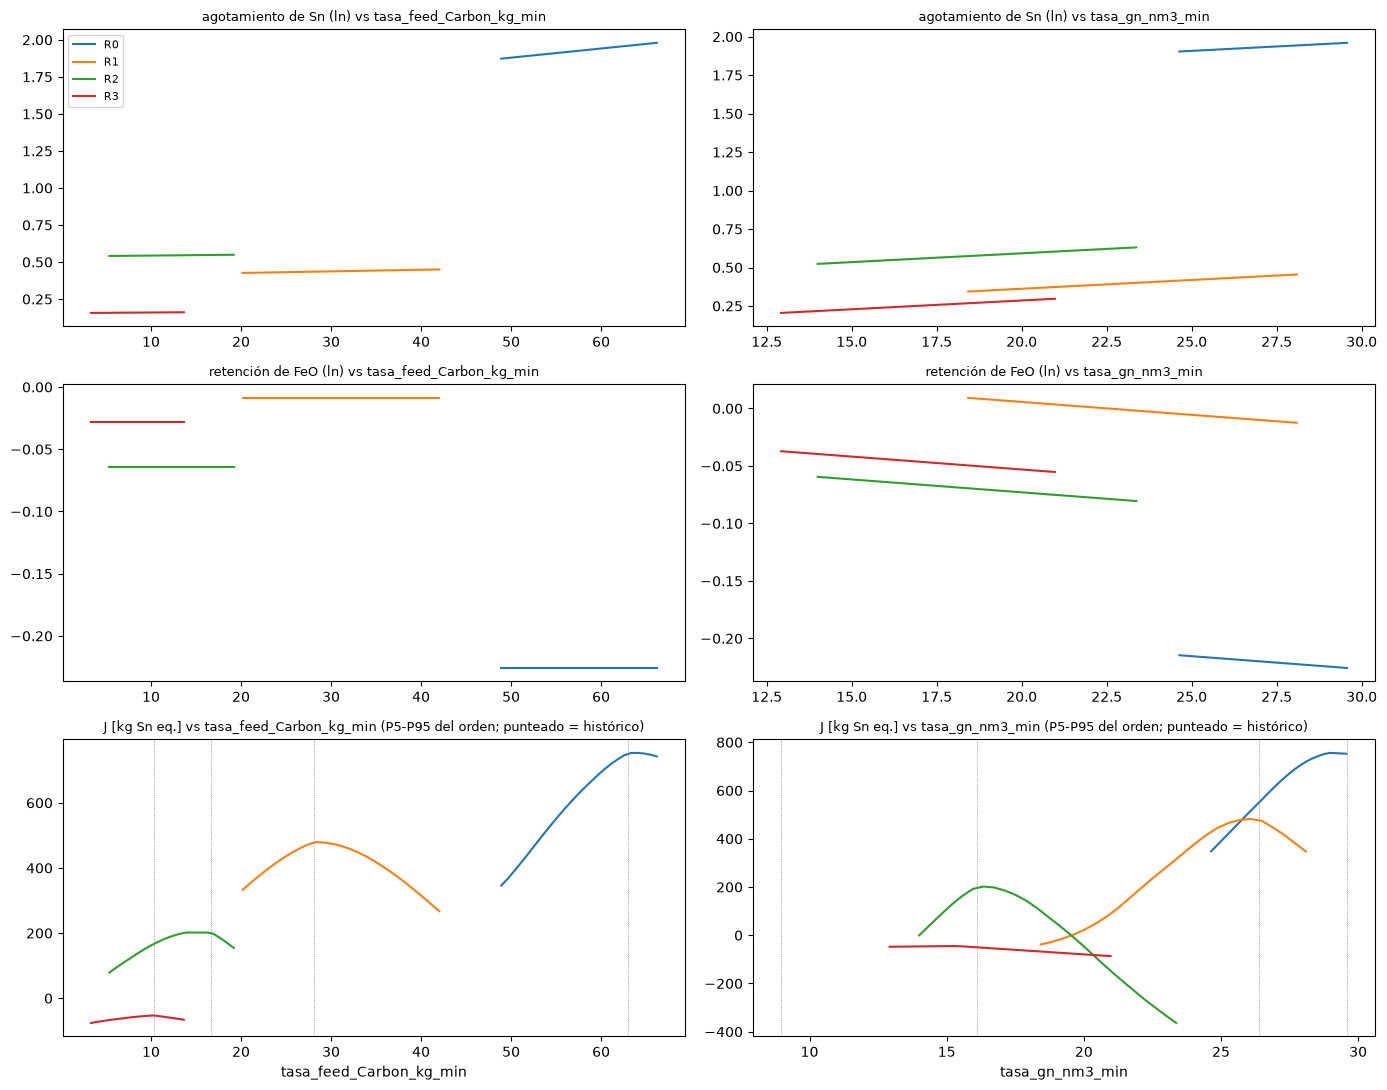

fracción de curvas J(palanca) con máximo interior (no en la cota P5/P95):


orden,0,1,2,3
palanca,,,,
tasa_feed_Carbon_kg_min,0.67,1.0,1.0,1.0
tasa_gn_nm3_min,1.00,1.0,1.0,1.0


In [11]:
cur = pd.read_csv(EXP / "e10_05_curvas_respuesta_v8.csv"); cur = cur[~cur.caja]
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for j, pal in enumerate(mp8.ACCIONES_OPTIMIZABLES_V8["Reducción"]):
    for (o, q), g in cur[(cur.palanca == pal) & (cur.q_avance == 0.5)].groupby(["orden", "q_avance"]):
        axes[0, j].plot(g.valor, g.pred_sn_dep, label=f"R{o}"); axes[1, j].plot(g.valor, g.pred_feo_ret, label=f"R{o}"); axes[2, j].plot(g.valor, g.J, label=f"R{o}")
        axes[2, j].axvline(g["hist"].iloc[0], color="grey", lw=0.6, ls=":")
    axes[0, j].set_title(f"agotamiento de Sn (ln) vs {pal}", fontsize=9); axes[1, j].set_title(f"retención de FeO (ln) vs {pal}", fontsize=9); axes[2, j].set_title(f"J [kg Sn eq.] vs {pal} (P5-P95 del orden; punteado = histórico)", fontsize=9); axes[2, j].set_xlabel(pal)
axes[0, 0].legend(fontsize=8); plt.tight_layout(); plt.show()
oi = pd.read_csv(EXP / "e10_05_optimo_interior.csv"); print("fracción de curvas J(palanca) con máximo interior (no en la cota P5/P95):"); display(oi.groupby(["palanca", "orden"])["interior"].mean().unstack().round(2))

**Lectura.** Las componentes responden de forma monótona a cada palanca dentro del rango histórico (θ lineal; la curvatura del
carbón tiene el signo de la teoría pero no se identifica, E10-01). `J` sí puede tener máximo interior por el intercambio Sn/FeO del GN
(sube agotamiento, baja retención) y por el costo; para el carbón, sin efecto identificado sobre FeO, `J` es lineal y la recomendación
es un paso acotado en la dirección del signo de `K·θ·Sn_disp − costo` (más carbón mientras el Sn disponible lo paga, menos cuando ya no).

## 6. Capa prescriptiva: objetivo, salvaguardas y recomendación por escalón

- **Reducción:** `J = K·(ln_sn_dep + w·ln_feo_ret) − 0.05·C·Δt − 0.03·GN·Δt − 0.01·O₂·Δt − 0.5·sd_J(acción) − 2000·max(0, s_hist − s)`
  (kg de Sn a metal equivalente); búsqueda en grilla dentro de la **caja por orden** (P5-P95 ∩ |Δ| ≤ 1 sd; carbón R0 ≤ P90), acción histórica
  siempre admisible, soporte del estado ≥ P10 (si no: "sin recomendación"), ventana térmica dura relativa (no enfriar un horno frío ni
  calentar uno caliente), O₂ y aire congelados al plan; **sin ganancia física** (K·Δ(ln_sn_dep + w·ln_feo_ret) ≤ 0) la recomendación se degrada a
  `mantener:solo_costo` (precios placeholder); el **GN sólo se mueve si su dirección se conserva en los extremos del IC de w** [3.96, 9.62]
  (sensibilidad E10-05). Estados: `recomendar`, `mantener`, `mantener:solo_costo`, `sin_recomendacion:{soporte, orden, estado, receta}`.
- **Fusión:** receta (F1-F6 sin recomendación por escalón); el recorte económico de carbón (≤ 1 sd, ≥ P10, −O₂ 0.933 Nm³/kg C) sólo con precios reales.
- **Dos modos de estado** (E10-03): `k15` (ensayo del cierre de t−1; re-plan cuando llega el laboratorio) y `plan` (cierre de F6 + variables en
  línea: plan R0-R3 al inicio de la Reducción, ejecutable sin latencia; conserva ~92 % del R² de Sn e identifica carbón y GN).

,0,1,2,3,4,5,6,7,8,9
fase,Fusión,Fusión,Fusión,Fusión,Fusión,Fusión,Reducción,Reducción,Reducción,Reducción
orden_escalon_fase,1,2,3,4,5,6,0,1,2,3
estado_recomendacion,sin_recomendacion:orden,sin_recomendacion:receta,sin_recomendacion:receta,sin_recomendacion:receta,sin_recomendacion:receta,sin_recomendacion:soporte,sin_recomendacion:soporte,sin_recomendacion:soporte,sin_recomendacion:soporte,recomendar
m6_avance_prev,0.692,0.552,0.556,0.565,0.575,0.58,0.624,0.908,0.974,0.977
pred_sn_dep_hist,NaN,NaN,NaN,NaN,NaN,NaN,1.76,1.234,0.267,0.217
pred_sn_dep_rec,NaN,NaN,NaN,NaN,NaN,NaN,1.76,1.234,0.267,0.217
pred_feo_ret_hist,NaN,NaN,NaN,NaN,NaN,NaN,-0.16,-0.147,-0.039,-0.039
pred_feo_ret_rec,NaN,NaN,NaN,NaN,NaN,NaN,-0.16,-0.147,-0.039,-0.038
pred_T_historico,1010.503,1003.757,999.423,990.66,977.125,971.283,955.319,944.191,951.056,959.937
pred_T_recomendado,1010.503,1003.757,999.423,990.66,977.125,971.283,955.319,944.191,951.056,960.258


{'J_R_temprano_hist_pp': 3.269, 'J_R_tardio_hist_pp': 0.066, 'J_R_hist_pp': 3.335, 'dSn_hist': 3.479, 'dFeO_hist': -0.384, 'J_F_hist_pp': -0.0, 'J_batch_hist_pp': 3.335, 'J_R_temprano_rec_pp': 3.269, 'J_R_tardio_rec_pp': 0.073, 'J_R_rec_pp': 3.342, 'dSn_rec': 3.478, 'dFeO_rec': -0.384, 'J_F_rec_pp': -0.0, 'J_batch_rec_pp': 3.342, 'uplift_batch_pp': 0.007, 'uplift_batch_kg': 3.779}


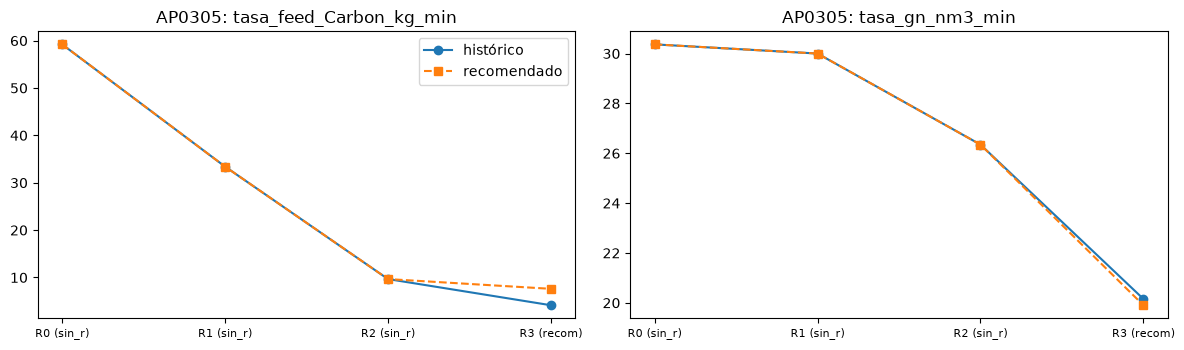

In [12]:
batch_id = sorted(batches_lockbox)[5]
rep = mp8.reporte_recomendaciones_batch_v8(sistema, df, batch_id)
cols = ["fase", "orden_escalon_fase", "estado_recomendacion", "m6_avance_prev", "pred_sn_dep_hist", "pred_sn_dep_rec", "pred_feo_ret_hist", "pred_feo_ret_rec",
        "pred_T_historico", "pred_T_recomendado", "support_historico", "support_recomendado", "uplift_J_kgSn", "hist__tasa_feed_Carbon_kg_min", "rec__tasa_feed_Carbon_kg_min",
        "hist__tasa_gn_nm3_min", "rec__tasa_gn_nm3_min", "hist__tasa_o2_nm3_min", "rec__tasa_o2_nm3_min"]
display(rep[[c for c in cols if c in rep.columns]].round(3).T)
print({k: round(v, 3) for k, v in mp8.agregar_objetivo(rep).items()})
r = rep[rep.fase == "Reducción"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, pal in zip(axes, mp8.ACCIONES_OPTIMIZABLES_V8["Reducción"]):
    x = np.arange(len(r)); ax.plot(x, r[f"hist__{pal}"], "o-", label="histórico"); ax.plot(x, r[f"rec__{pal}"], "s--", label="recomendado")
    ax.set_xticks(x); ax.set_xticklabels([f"R{o} ({e.split(':')[0][:5]})" for o, e in zip(r.orden_escalon_fase, r.estado_recomendacion)], fontsize=8); ax.set_title(f"{batch_id}: {pal}")
axes[0].legend(); plt.tight_layout(); plt.show()

estado_recomendacion          mantener  mantener:solo_costo  recomendar  sin_recomendacion:estado  sin_recomendacion:orden  sin_recomendacion:receta  sin_recomendacion:soporte
fase      orden_escalon_fase                                                                                                                                                   
Fusión    1                       0.00                 0.00        0.00                      0.01                     0.99                      0.00                       0.00
          2                       0.00                 0.00        0.00                      0.01                     0.00                      0.86                       0.14
          3                       0.00                 0.00        0.00                      0.01                     0.00                      0.85                       0.14
          4                       0.00                 0.00        0.00                      0.01                     0.00                      0.86                       0.13
          5                       0.00                 0.00        0.00                      0.01                     0.00                      0.84                       0.15
          6                       0.00                 0.00        0.00                      0.02                     0.00                      0.73                       0.25
Reducción 0                       0.10                 0.09        0.58                      0.00                     0.00                      0.00                       0.22
          1                       0.17                 0.19        0.41                      0.01                     0.00                      0.00                       0.22
          2                       0.20                 0.22        0.41                      0.02                     0.00                      0.00                       0.16
          3                       0.24                 0.25        0.39                      0.02                     0.00                      0.00                       0.11

,orden,palanca,n,hist_P50,delta_P5,delta_P50,delta_P95,pct_cambia,pct_sube,pct_baja,pct_abs_delta_mayor_1sd,pct_rec_mayor_P95,pct_rec_menor_P5,pct_rec_en_borde_caja,pct_rec_mayor_P90
0,0,tasa_feed_Carbon_kg_min,280,62.6,-5.4,0.7,7.0,72.5,56.1,16.4,0.0,2.9,0.4,3.6,18.2
1,0,tasa_gn_nm3_min,280,28.3,-2.1,0.0,1.8,73.6,40.0,33.6,0.0,11.1,0.0,2.5,NaN
2,1,tasa_feed_Carbon_kg_min,279,29.7,-6.8,0.0,6.8,52.3,26.2,26.2,0.0,3.9,1.8,1.8,NaN
3,1,tasa_gn_nm3_min,279,25.0,-2.0,0.0,2.9,47.7,26.5,21.1,0.0,4.7,0.4,0.4,NaN
4,2,tasa_feed_Carbon_kg_min,299,11.1,-5.7,0.0,4.4,48.2,20.7,27.4,0.0,2.3,1.0,2.0,NaN
5,2,tasa_gn_nm3_min,299,18.8,-2.0,0.0,2.7,46.8,26.8,20.1,0.0,2.0,0.3,0.3,NaN
6,3,tasa_feed_Carbon_kg_min,316,5.6,-3.5,0.0,3.1,43.4,18.0,25.3,0.0,5.1,5.1,2.5,NaN
7,3,tasa_gn_nm3_min,316,16.7,-1.7,0.0,2.4,38.6,21.8,16.8,0.0,3.8,0.9,0.6,NaN


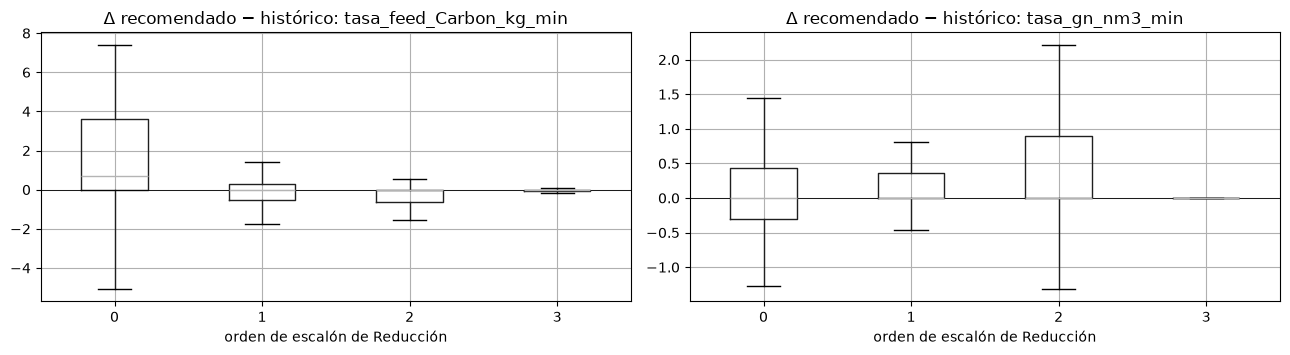

In [13]:
# Politica cross-fitted (cada batch recomendado por un sistema que no lo vio; 362 batches): perfil por orden y salvaguardas del comite
esc = pd.read_csv(EXP / "e10_05_recomendaciones_v8_escalones.csv")
display(pd.crosstab([esc.fase, esc.orden_escalon_fase], esc.estado_recomendacion, normalize="index").round(2))
mag = pd.read_csv(EXP / "e10_05_magnitud_cambios.csv")
display(mag[mag.fase == "Reducción"][["orden", "palanca", "n", "hist_P50", "delta_P5", "delta_P50", "delta_P95", "pct_cambia", "pct_sube", "pct_baja", "pct_abs_delta_mayor_1sd", "pct_rec_mayor_P95", "pct_rec_menor_P5", "pct_rec_en_borde_caja"] + (["pct_rec_mayor_P90"] if "pct_rec_mayor_P90" in mag.columns else [])].round(1))
e = esc[(esc.fase == "Reducción") & esc.estado_recomendacion.isin(["recomendar", "mantener", "mantener:solo_costo"])].copy()
for a in mp8.ACCIONES_OPTIMIZABLES_V8["Reducción"]: e[f"d_{a}"] = e[f"rec__{a}"] - e[f"hist__{a}"]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, a in zip(axes, mp8.ACCIONES_OPTIMIZABLES_V8["Reducción"]):
    e.boxplot(column=f"d_{a}", by="orden_escalon_fase", ax=ax, showfliers=False); ax.axhline(0, color="k", lw=0.6); ax.set_title(f"Δ recomendado − histórico: {a}"); ax.set_xlabel("orden de escalón de Reducción")
plt.suptitle(""); plt.tight_layout(); plt.show()

In [14]:
# Robustez de la politica al objetivo (E10-05 sensibilidad): % de escalones con el mismo signo que la base bajo w in [2, 11], legado y objetivo lineal en kg
sens = pd.read_csv(EXP / "e10_05_sensibilidad_resumen.csv")
print("% de escalones con signo estrictamente opuesto a la base (carbon robusto <= 7 %; GN sensible al peso del FeO bajo el objetivo lineal en kg):")
display(sens.pivot_table(index=["palanca", "orden"], columns="variante", values="pct_signo_opuesto").round(0))
display(sens.pivot_table(index=["palanca", "orden"], columns="variante", values="delta_medio_variante").round(2))

% de escalones con signo estrictamente opuesto a la base (carbon robusto <= 7 %; GN sensible al peso del FeO bajo el objetivo lineal en kg):


variante                       base  legado_K3.52_w7.86  lineal_kg_l1  lineal_kg_l3  lineal_kg_l4.7  w11   w2   w4  w_eiv_7.4
palanca                 orden                                                                                                
tasa_feed_Carbon_kg_min 0       0.0                 0.0           0.0           7.0             7.0  0.0  3.0  2.0        0.0
                        1       0.0                 0.0           0.0           3.0             5.0  2.0  2.0  2.0        0.0
                        2       0.0                 0.0           0.0           2.0             3.0  0.0  0.0  0.0        0.0
                        3       0.0                 0.0           0.0           2.0             5.0  0.0  0.0  0.0        0.0
tasa_gn_nm3_min         0       0.0                 0.0           0.0          12.0            13.0  2.0  0.0  0.0        0.0
                        1       0.0                 0.0           2.0          10.0            12.0  5.0  0.0  0.0        0.0
                        2       0.0                 0.0           2.0          12.0            15.0  2.0  0.0  0.0        0.0
                        3       0.0                 0.0           5.0           7.0            13.0  5.0  0.0  0.0        0.0

variante                       base  legado_K3.52_w7.86  lineal_kg_l1  lineal_kg_l3  lineal_kg_l4.7   w11    w2    w4  w_eiv_7.4
palanca                 orden                                                                                                   
tasa_feed_Carbon_kg_min 0     -0.73               -1.28         -0.82         -0.25           -0.29 -0.96 -0.72 -0.92      -1.32
                        1     -0.83               -1.42         -1.35         -1.76           -1.77 -1.55 -1.94 -2.23      -1.42
                        2     -0.67               -0.88         -0.98         -1.11           -1.07 -0.95 -0.88 -0.94      -0.84
                        3     -0.57               -0.43         -0.52         -0.40           -0.38 -0.53 -0.67 -0.69      -0.44
tasa_gn_nm3_min         0      0.12               -0.42          0.05         -0.93           -1.19 -0.65  0.44  0.29      -0.40
                        1      0.32               -0.53         -0.64         -1.33           -1.65 -0.72  0.95  0.79      -0.52
                        2      0.37               -0.56         -0.64         -1.14           -1.62 -0.65  0.60  0.56      -0.54
                        3      0.36               -0.37         -0.54         -0.77           -1.05 -0.53  0.50  0.49      -0.35

## 7. Sustento: ¿aplicar las recomendaciones conduce a mayor rendimiento del batch?

Cadena de evidencia con potencia en cada eslabón (el comité descartó la regresión de adherencia sobre el KPI por falta de potencia: se
reporta sólo como monitoreo):

1. **Palanca → target por escalón (n ≈ 1 000):** θ con IC libre (sección 2) y dosis-respuesta no paramétrica del residuo de la acción
   (sección 5): más carbón (por Sn disponible) → más agotamiento; menos GN → más retención de FeO, en el signo de la teoría.
2. **Residuo de la acción → KPI del batch, sin pasar por el modelo:** la desviación del operador respecto de lo que el estado predice
   (a − E[a|S]) agregada por batch se relaciona con el KPI en el signo que dicta la política.
3. **Target → KPI (anclaje, sección 1.1):** Σ ln_sn_dep y Σ ln_feo_ret suben la recuperación refinada (p < 1e-4), y la retención de FeO
   replica sobre el batch siguiente en el lockbox (legado).
4. **Uplift con IC propagado y evaluación cruzada:** el cambio predicho por la política se valora con (K, w) bootstrap y un factor de θ, y
   se re-evalúa con un modelo que no eligió la acción (otro fold) y con un HGB directo: corrige la maldición del optimizador.

In [15]:
dre = pd.read_csv(EXP / "e10_05_dosis_respuesta.csv")
print("2) residuo de la accion (a - E[a|S]) agregado por batch -> KPI refinado (OLS HC3 con controles, Spearman):")
display(dre[dre.clave.str.startswith("batch")][["clave", "palanca", "grupo", "n", "spearman_residual", "p", "ols_pp_por_sd", "ols_p"]].round(4))
up = pd.read_csv(EXP / "e10_05_uplift_propagado.csv"); print("4a) uplift por batch (pp de KPI) con IC propagado:"); display(up.round(3))
cz = pd.read_csv(EXP / "e10_05_evaluacion_cruzada_resumen.csv"); print("4b) evaluacion cruzada (Δ J predicho por el optimizador vs por un modelo que no eligio la accion vs HGB directo):"); display(cz.round(4).T)

2) residuo de la accion (a - E[a|S]) agregado por batch -> KPI refinado (OLS HC3 con controles, Spearman):


,clave,palanca,grupo,n,spearman_residual,p,ols_pp_por_sd,ols_p
4,batch_sn_dep,Cx_sn_v6,R_temprano,295,-0.1026,0.0786,-0.2782,0.2417
5,batch_sn_dep,Cx_sn_v6,R_tardio,292,0.1853,0.0015,0.8109,0.0154
6,batch_sn_dep,Cx_sn_v6,R_todo,297,-0.0719,0.2169,-0.2017,0.4275
7,batch_sn_dep,tasa_gn_nm3_min,R_temprano,295,-0.0335,0.5667,-0.3374,0.1748
8,batch_sn_dep,tasa_gn_nm3_min,R_tardio,292,-0.0749,0.2016,-0.4173,0.0826
9,batch_sn_dep,tasa_gn_nm3_min,R_todo,297,-0.0877,0.1316,-0.4622,0.0429
10,batch_sn_dep,exceso_o2_combustion_pct,R_temprano,295,0.0048,0.9341,0.2068,0.3472
11,batch_sn_dep,exceso_o2_combustion_pct,R_tardio,292,0.0292,0.6189,0.2427,0.2985
12,batch_sn_dep,exceso_o2_combustion_pct,R_todo,297,0.0256,0.6606,0.3230,0.1504
13,batch_sn_dep,tasa_aire_nm3_min,R_temprano,295,0.0112,0.8477,-0.0634,0.7655


4a) uplift por batch (pp de KPI) con IC propagado:


,n_batches,uplift_medio_pp_puntual,uplift_medio_pp_mediana,ic_lo,ic_hi,prob_positivo,subset,propaga
0,288,0.072,0.074,0.049,0.101,1.0,DEV,solo_Kw
1,288,0.072,0.071,0.038,0.121,1.0,DEV,Kw_y_theta
2,63,0.060,0.062,0.039,0.088,1.0,LOCKBOX,solo_Kw
3,63,0.060,0.059,0.031,0.104,1.0,LOCKBOX,Kw_y_theta
4,351,0.070,0.072,0.048,0.096,1.0,TOTAL,solo_Kw
5,351,0.070,0.070,0.037,0.117,1.0,TOTAL,Kw_y_theta


4b) evaluacion cruzada (Δ J predicho por el optimizador vs por un modelo que no eligio la accion vs HGB directo):


,0
n_escalones,555.0000
dJ_opt_media_pp,0.0373
dJ_opt_frac_pos,1.0000
dJ_cruzado_media_pp,0.0100
dJ_cruzado_frac_pos,0.7027
dJ_hgb_media_pp,-0.0432
dJ_hgb_frac_pos,0.4144
corr_opt_cruzado,0.6306
corr_opt_hgb,-0.0336
ratio_cruzado_opt,0.2690


Monitoreo (sin potencia para probar, dictamen §3): adherencia (dist_*) y direccion (dir_*) vs KPI, OLS HC3 con controles


coef_por_sd                 p_hc3               
subset                                                                       DEV LOCKBOX  TOTAL    DEV LOCKBOX  TOTAL
kpi                            variable                                                                              
f_dross                        dir_Reducción_tasa_feed_Carbon_kg_min       0.001  -0.010 -0.001  0.718   0.015  0.611
                               dir_Reducción_tasa_gn_nm3_min              -0.003   0.004 -0.001  0.155   0.363  0.510
                               dist_R                                     -0.001  -0.012 -0.001  0.751   0.013  0.550
                               uplift_batch_pp                             0.001  -0.005  0.002  0.500   0.319  0.440
f_polvo                        dir_Reducción_tasa_feed_Carbon_kg_min       0.001   0.002  0.002  0.458   0.661  0.353
                               dir_Reducción_tasa_gn_nm3_min              -0.000  -0.002 -0.001  0.938   0.728  0.752
                               dist_R                                      0.001   0.000  0.001  0.537   0.990  0.606
                               uplift_batch_pp                             0.002  -0.001  0.001  0.309   0.773  0.391
recuperacion_refinada_pct      dir_Reducción_tasa_feed_Carbon_kg_min      -0.225   0.861 -0.075  0.394   0.079  0.763
                               dir_Reducción_tasa_gn_nm3_min               0.307  -0.390  0.171  0.221   0.570  0.458
                               dist_R                                     -0.075   1.311  0.022  0.775   0.033  0.924
                               uplift_batch_pp                            -0.321   0.787 -0.261  0.227   0.177  0.276
recuperacion_refinada_pct_next dir_Reducción_tasa_feed_Carbon_kg_min       0.007  -0.803 -0.078  0.980   0.207  0.774
                               dir_Reducción_tasa_gn_nm3_min               0.201   0.168  0.135  0.444   0.737  0.567
                               dist_R                                     -0.035  -0.680 -0.155  0.899   0.341  0.519
                               uplift_batch_pp                            -0.227  -0.110 -0.264  0.429   0.860  0.297

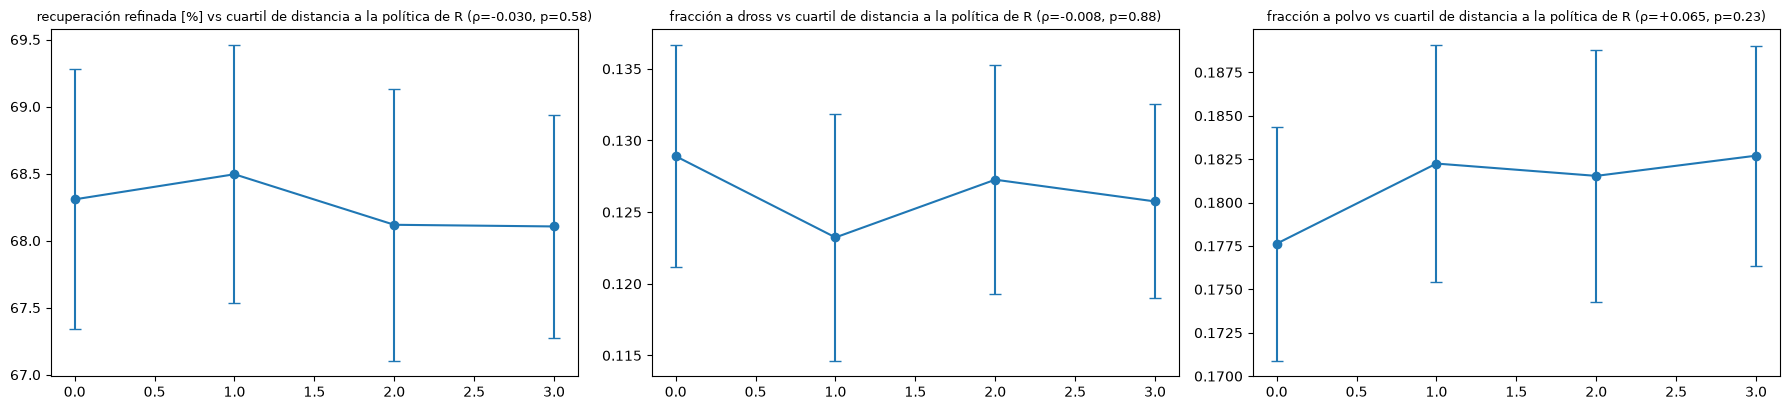

In [16]:
pb = pd.read_csv(EXP / "e10_05_por_batch_v8.csv"); ev = pd.read_csv(EXP / "e10_05_evidencia_politica_v8.csv")
print("Monitoreo (sin potencia para probar, dictamen §3): adherencia (dist_*) y direccion (dir_*) vs KPI, OLS HC3 con controles")
sel = ev[ev.variable.isin(["dist_R", "dir_Reducción_tasa_feed_Carbon_kg_min", "dir_Reducción_tasa_gn_nm3_min", "uplift_batch_pp"]) & ev.kpi.isin(["recuperacion_refinada_pct", "recuperacion_refinada_pct_next", "f_dross", "f_polvo"])]
display(sel.pivot_table(index=["kpi", "variable"], columns="subset", values=["coef_por_sd", "p_hc3"]).round(3))
fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))
for ax, (kpi, lab) in zip(axes, [("recuperacion_refinada_pct", "recuperación refinada [%]"), ("f_dross", "fracción a dross"), ("f_polvo", "fracción a polvo")]):
    d = pb.dropna(subset=["dist_R", kpi]).copy(); d["q"] = pd.qcut(d.dist_R, 4, labels=False, duplicates="drop"); g = d.groupby("q")[kpi].agg(["mean", "sem", "size"])
    ax.errorbar(g.index, g["mean"], yerr=1.96 * g["sem"], fmt="o-", capsize=4); rho, p = spearmanr(d.dist_R, d[kpi]); ax.set_title(f"{lab} vs cuartil de distancia a la política de R (ρ={rho:+.3f}, p={p:.2f})", fontsize=9)
plt.tight_layout(); plt.show()

## 8. Conclusiones, límites y siguiente paso

Ver `candidate_win_model_v8.md` (ficha: métricas OOF/cronológico/walk-forward/lockbox, fórmulas, hallazgos, positivo/negativo) y `hallazgos.md` §22.

- **Modelo ganador (Reducción):** PLM dual por target con estado de 15 variables físicas (sin relojes de campaña), targets telescópicos
  (agotamiento de Sn; retención de Fe neta del Fe alimentado) y objetivo anclado en el KPI refinado (K 2.78, w 5.93). Palancas
  identificadas con IC libre: carbón × Sn disponible (+Sn), GN (+Sn, −FeO). No identificadas (θ de uso 0, a resolver en el piloto por
  escalón): carbón → FeO, exceso de O₂, aire.
- **Prescripción:** pasos acotados (≤ 1 sd del orden, P5-P95, R0 ≤ P90) de carbón y GN por escalón de Reducción; sin recomendación fuera
  del soporte histórico; Fusión = receta; modo `plan` para operar sin esperar al laboratorio.
- **Evidencia:** identificación por escalón con potencia, anclaje target → KPI replicado, uplift con IC propagado y evaluación cruzada.
  Es observacional: la magnitud del valor sólo la fija el piloto aleatorizado por escalón (carbón R0-R1 ±1 sd ≈ 15-30 batches por brazo;
  GN ≈ 230), como pide el dictamen.